# 🛒 Retail Demand Forecasting
### *End-to-end ML Pipeline · Kaggle Store Sales Dataset*

[![Dataset](https://img.shields.io/badge/Dataset-Kaggle%20Store%20Sales-20BEFF?logo=kaggle&logoColor=white)](https://www.kaggle.com/competitions/store-sales-time-series-forecasting)
[![Python](https://img.shields.io/badge/Python-3.10-3776AB?logo=python&logoColor=white)](https://www.python.org/)
[![LightGBM](https://img.shields.io/badge/Model-LightGBM-9ACD32?logo=lightgbm&logoColor=white)](https://lightgbm.readthedocs.io/)
[![MLflow](https://img.shields.io/badge/Tracking-MLflow-0194E2?logo=mlflow&logoColor=white)](https://mlflow.org/)
[![SHAP](https://img.shields.io/badge/Explainability-SHAP-FF6B6B)](https://shap.readthedocs.io/)
[![Streamlit](https://img.shields.io/badge/Deployment-Streamlit-FF4B4B?logo=streamlit&logoColor=white)](https://streamlit.io/)

## Goal — SHAP Explainability
 A black-box model that predicts well but can't explain *why* will never be trusted by a merchandising or supply chain team

## 1. Setup

In [1]:
!pip install shap lightgbm joblib -q

In [3]:
from google.colab import drive
drive.mount('/content/drive')

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import shap
import joblib
import warnings
warnings.filterwarnings('ignore')

pd.set_option('display.float_format', lambda x: f'{x:,.4f}')
shap.initjs()

DATA_PATH  = '/content/drive/MyDrive/Colab Notebooks/Demand Forecasting Project/'
MODEL_PATH = DATA_PATH + 'models/'

Mounted at /content/drive


## 2. Load Model & Features

In [4]:
# Load trained model
model = joblib.load(MODEL_PATH + 'lgbm_model.pkl')

# Load feature panel
panel = pd.read_parquet(DATA_PATH + 'panel_features.parquet')

In [5]:
FEATURE_COLS = [
    'day_of_week', 'day_of_month', 'month', 'week_of_year',
    'year', 'is_weekend', 'quarter',
    'sales_lag_7', 'sales_lag_14', 'sales_lag_28',
    'rolling_mean_7', 'rolling_mean_28', 'rolling_std_7',
    'oil_lag1', 'oil_rolling7',
    'is_holiday', 'days_to_holiday',
    'store_nbr', 'cluster',
    'family', 'type', 'city', 'state',
    'onpromotion'
]

CAT_COLS = ['family', 'type', 'city', 'state']
for col in CAT_COLS:
    panel[col] = panel[col].astype('category')

# Use validation set only (post May 2017)
val = panel[panel['date'] >= '2017-05-01'].copy()
X_val = val[FEATURE_COLS]

print(f'Validation rows: {len(X_val):,}')

Validation rows: 190,674


## 3. Compute SHAP Values

In [6]:
# Stratified sample across families for representative SHAP values
sample = val.groupby('family', observed=True).apply(
    lambda g: g.sample(min(100, len(g)), random_state=42)
).reset_index(drop=True)

X_sample = sample[FEATURE_COLS]
print(f'SHAP sample size : {len(X_sample):,} rows across {X_sample["family"].nunique()} families')

# Compute SHAP values
explainer   = shap.TreeExplainer(model)
shap_values = explainer.shap_values(X_sample)

print(f'SHAP values shape: {shap_values.shape}')
print('SHAP computation complete ✓')

SHAP sample size : 3,300 rows across 33 families
SHAP values shape: (3300, 24)
SHAP computation complete ✓


## 4. Global Feature Importance — Bar Chart

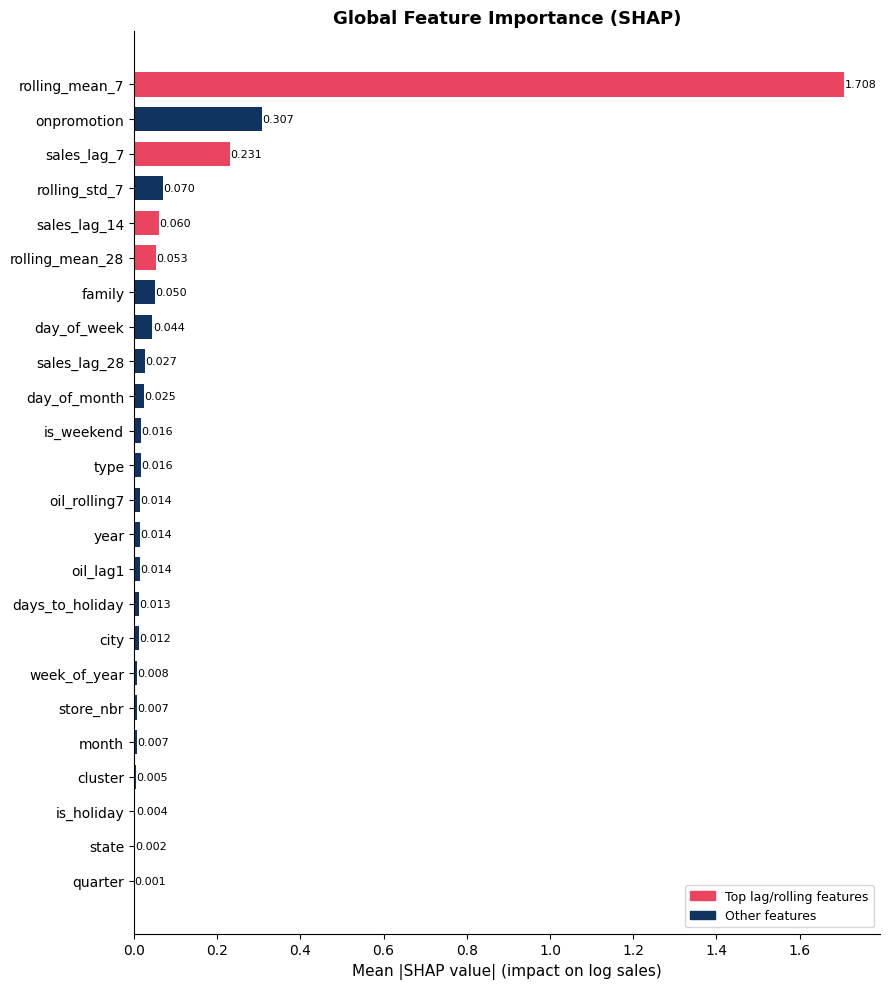


Top 5 most important features:
       feature  importance
rolling_mean_7      1.7078
   onpromotion      0.3071
   sales_lag_7      0.2312
 rolling_std_7      0.0698
  sales_lag_14      0.0599


In [7]:
mean_abs_shap = pd.DataFrame({
    'feature'    : FEATURE_COLS,
    'importance' : np.abs(shap_values).mean(axis=0)
}).sort_values('importance', ascending=True)

fig, ax = plt.subplots(figsize=(9, 10))

colors = ['#e94560' if f in ['sales_lag_7','rolling_mean_7','rolling_mean_28','sales_lag_14']
          else '#0f3460' for f in mean_abs_shap['feature']]

bars = ax.barh(mean_abs_shap['feature'], mean_abs_shap['importance'],
               color=colors, edgecolor='none', height=0.7)

for bar, val in zip(bars, mean_abs_shap['importance']):
    ax.text(val + 0.001, bar.get_y() + bar.get_height()/2,
            f'{val:.3f}', va='center', fontsize=8)

ax.set_xlabel('Mean |SHAP value| (impact on log sales)', fontsize=11)
ax.set_title('Global Feature Importance (SHAP)', fontsize=13, fontweight='bold')

from matplotlib.patches import Patch
ax.legend(handles=[
    Patch(color='#e94560', label='Top lag/rolling features'),
    Patch(color='#0f3460', label='Other features')
], fontsize=9)

ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
plt.tight_layout()
plt.savefig(DATA_PATH + 'shap_bar.png', dpi=120, bbox_inches='tight')
plt.show()

print('\nTop 5 most important features:')
print(mean_abs_shap.tail(5)[['feature','importance']].iloc[::-1].to_string(index=False))

## 5. Beeswarm Plot — Direction + Magnitude

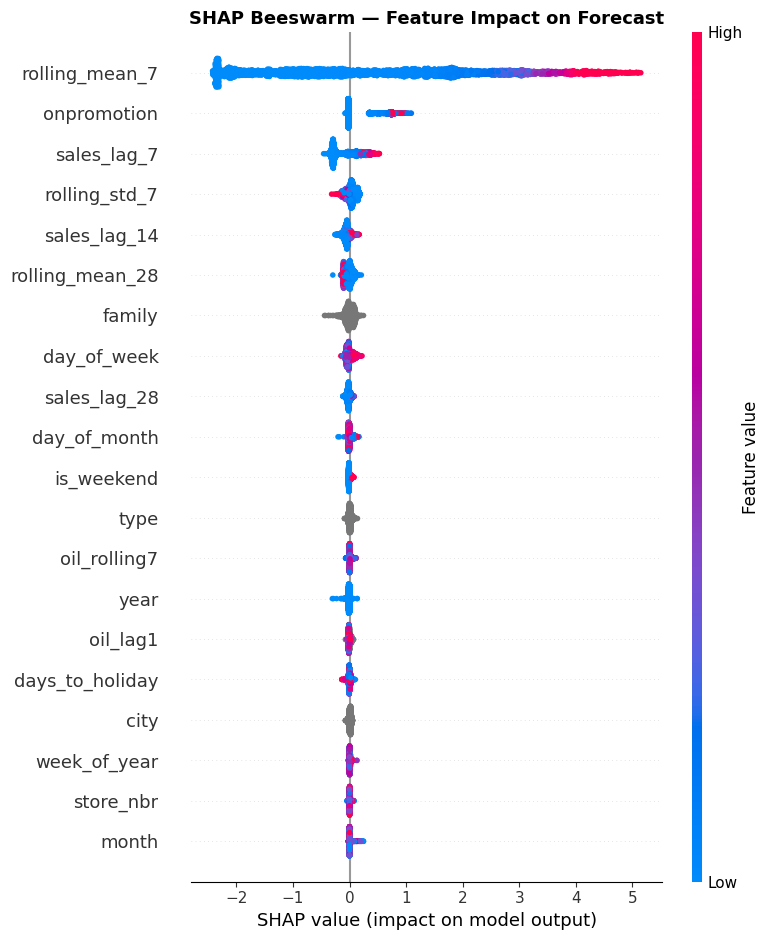

Beeswarm saved ✓


In [8]:
plt.figure(figsize=(10, 9))
shap.summary_plot(
    shap_values,
    X_sample,
    feature_names=FEATURE_COLS,
    plot_type='dot',
    max_display=20,
    show=False
)
plt.title('SHAP Beeswarm — Feature Impact on Forecast', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig(DATA_PATH + 'shap_beeswarm.png', dpi=120, bbox_inches='tight')
plt.show()
print('Beeswarm saved ✓')

## 6. Waterfall Plot — Single Prediction Breakdown

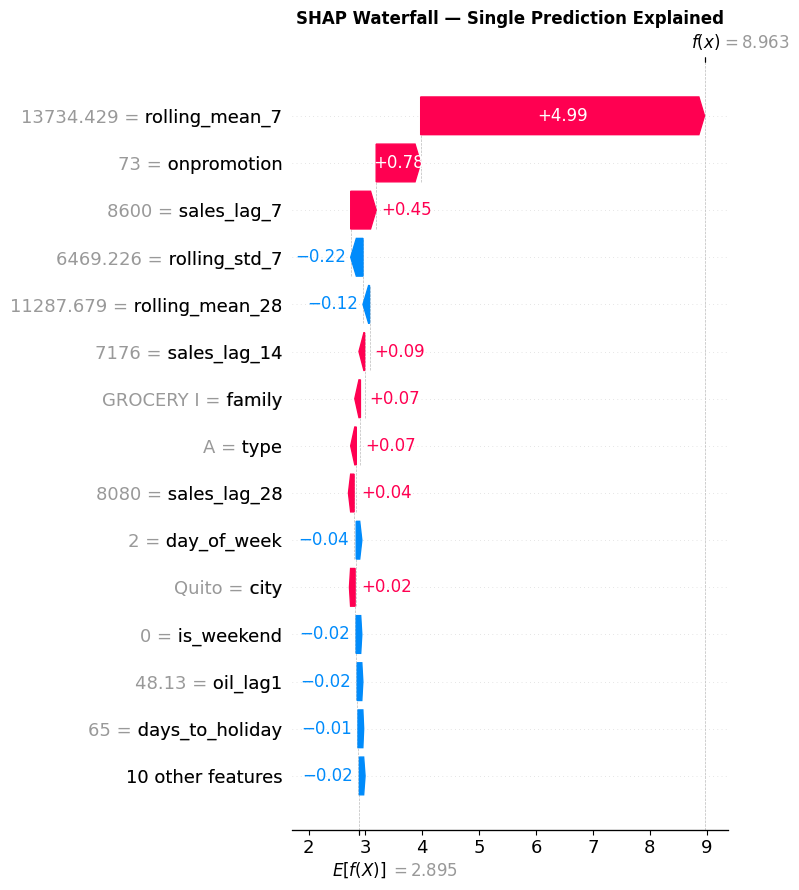

Explaining prediction for:
  Store   : 46
  Family  : GROCERY I
  Date    : 2017-06-07
  Actual  : 10,797 units
  Lag 7d  : 8,600 units


In [9]:
# Pick a high-sales prediction row — more interesting to explain
high_sales_idx = X_sample['rolling_mean_7'].nlargest(1).index[0]
row_pos = X_sample.index.get_loc(high_sales_idx)

explanation = shap.Explanation(
    values        = shap_values[row_pos],
    base_values   = explainer.expected_value,
    data          = X_sample.iloc[row_pos].values,
    feature_names = FEATURE_COLS
)

plt.figure(figsize=(10, 7))
shap.plots.waterfall(explanation, max_display=15, show=False)
plt.title('SHAP Waterfall — Single Prediction Explained', fontsize=12, fontweight='bold')
plt.tight_layout()
plt.savefig(DATA_PATH + 'shap_waterfall.png', dpi=120, bbox_inches='tight')
plt.show()

# Print the actual row context
row_data = sample.iloc[row_pos]
print(f'Explaining prediction for:')
print(f'  Store   : {row_data["store_nbr"]}')
print(f'  Family  : {row_data["family"]}')
print(f'  Date    : {row_data["date"].date()}')
print(f'  Actual  : {row_data["sales"]:,.0f} units')
print(f'  Lag 7d  : {row_data["sales_lag_7"]:,.0f} units')

## 7. Dependence Plot — Promotion Effect

<Figure size 1000x500 with 0 Axes>

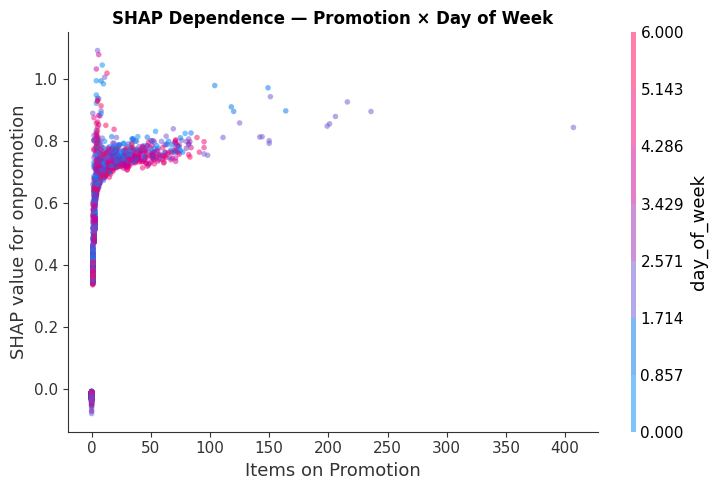

Dependence plot saved ✓


In [10]:
promo_idx = FEATURE_COLS.index('onpromotion')
dow_idx   = FEATURE_COLS.index('day_of_week')

plt.figure(figsize=(10, 5))
shap.dependence_plot(
    promo_idx,
    shap_values,
    X_sample,
    feature_names=FEATURE_COLS,
    interaction_index=dow_idx,
    show=False,
    alpha=0.5
)
plt.title('SHAP Dependence — Promotion × Day of Week', fontsize=12, fontweight='bold')
plt.xlabel('Items on Promotion')
plt.ylabel('SHAP value for onpromotion')
plt.tight_layout()
plt.savefig(DATA_PATH + 'shap_dependence_promo.png', dpi=120, bbox_inches='tight')
plt.show()
print('Dependence plot saved ✓')

## 8. Dependence Plot — Lag 7 Effect

<Figure size 1000x500 with 0 Axes>

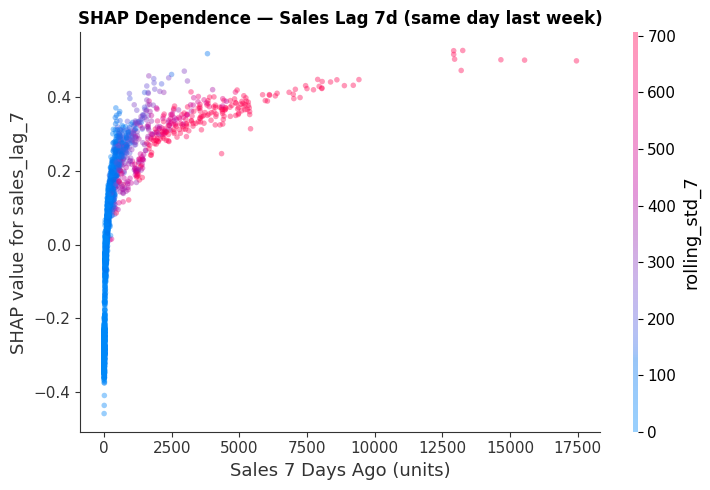

Lag 7 dependence plot saved ✓


In [11]:
lag7_idx = FEATURE_COLS.index('sales_lag_7')

plt.figure(figsize=(10, 5))
shap.dependence_plot(
    lag7_idx,
    shap_values,
    X_sample,
    feature_names=FEATURE_COLS,
    interaction_index='auto',
    show=False,
    alpha=0.4
)
plt.title('SHAP Dependence — Sales Lag 7d (same day last week)', fontsize=12, fontweight='bold')
plt.xlabel('Sales 7 Days Ago (units)')
plt.ylabel('SHAP value for sales_lag_7')
plt.tight_layout()
plt.savefig(DATA_PATH + 'shap_dependence_lag7.png', dpi=120, bbox_inches='tight')
plt.show()
print('Lag 7 dependence plot saved ✓')

## 9. Key Findings Summary

In [13]:
top5 = mean_abs_shap.tail(5)['feature'].iloc[::-1].tolist()
top5_vals = mean_abs_shap.tail(5)['importance'].iloc[::-1].tolist()

print('SHAP Key Findings Summary')
print('Top 5 demand drivers (by mean |SHAP|):')
for i, (f, v) in enumerate(zip(top5, top5_vals), 1):
    print(f'{i}. {f:<30} {v:.4f}')

# Save SHAP importance to CSV
mean_abs_shap.sort_values('importance', ascending=False).to_csv(
    DATA_PATH + 'shap_importance.csv', index=False
)

print('\nSaved: shap_importance.csv')

SHAP Key Findings Summary
Top 5 demand drivers (by mean |SHAP|):
1. rolling_mean_7                 1.7078
2. onpromotion                    0.3071
3. sales_lag_7                    0.2312
4. rolling_std_7                  0.0698
5. sales_lag_14                   0.0599

Saved: shap_importance.csv


In [19]:
!pip install streamlit -q

# Kill anything on 8501
!kill -9 $(lsof -t -i:8501) 2>/dev/null || true

import subprocess, time, urllib.request

# Start streamlit
proc = subprocess.Popen([
    'streamlit', 'run',
    '/content/drive/MyDrive/Colab Notebooks/Demand Forecasting Project/app.py',
    '--server.port', '8501',
    '--server.headless', 'true',
    '--server.enableCORS', 'false',
    '--server.enableXsrfProtection', 'false',
    '--server.maxUploadSize', '50'
], stdout=subprocess.DEVNULL, stderr=subprocess.DEVNULL)

time.sleep(6)
print('Streamlit running ✓')

# Use cloudflare tunnel — no account, no JS issues
!curl -sL https://github.com/cloudflare/cloudflared/releases/latest/download/cloudflared-linux-amd64 -o cloudflared
!chmod +x cloudflared

tunnel = subprocess.Popen(
    ['./cloudflared', 'tunnel', '--url', 'http://localhost:8501'],
    stdout=subprocess.PIPE,
    stderr=subprocess.STDOUT
)

print('Waiting for tunnel...')
for line in tunnel.stdout:
    line = line.decode()
    if 'trycloudflare.com' in line:
        # Extract URL from the log line
        import re
        urls = re.findall(r'https://[^\s]+trycloudflare\.com', line)
        if urls:
            print(f'\n🚀 App is live at: {urls[0]}')
            print('No password needed — open directly in browser')
            break

Streamlit running ✓
Waiting for tunnel...

🚀 App is live at: https://surprise-suites-maritime-river.trycloudflare.com
No password needed — open directly in browser


In [20]:
import urllib.request
try:
    r = urllib.request.urlopen('http://localhost:8501', timeout=3)
    print('Streamlit is running ✓')
except:
    print('Streamlit NOT running — restart it first')

Streamlit is running ✓


In [21]:
import subprocess, time, re, urllib.request

# Fresh tunnel
tunnel = subprocess.Popen(
    ['./cloudflared', 'tunnel', '--url', 'http://localhost:8501'],
    stdout=subprocess.PIPE,
    stderr=subprocess.STDOUT
)

# Get the URL
url = None
for line in tunnel.stdout:
    line = line.decode()
    urls = re.findall(r'https://[^\s]+trycloudflare\.com', line)
    if urls:
        url = urls[0]
        print(f'Tunnel URL: {url}')
        break

# Wait until it actually responds
print('Waiting for URL to go live', end='')
for i in range(30):
    try:
        urllib.request.urlopen(url, timeout=3)
        print(f'\n\n🚀 Ready! Open this: {url}')
        break
    except:
        print('.', end='', flush=True)
        time.sleep(3)
else:
    print('\nTimed out — paste the URL and try opening it manually')

Tunnel URL: https://modes-testimonials-whats-interaction.trycloudflare.com
Waiting for URL to go live..........

🚀 Ready! Open this: https://modes-testimonials-whats-interaction.trycloudflare.com
